# Seaborn Matrix, Joint & Multi-Plot Grids: Beginner Guide

### 🌟 What Are Seaborn Matrix Heatmaps, Joint & Multi-Plot Grids?
Understanding multi-variable relationships is essential during exploratory data analysis. This notebook covers correlation **Heatmaps** (`heatmap`), bivariate **JointGrids** (`jointplot`), and pairwise feature matrices (**`pairplot`**) with automatic categorical color palettes.

This interactive guide loads and works directly with `data/raw_transactions.csv`, giving you real-world hands-on practice.

### 📚 Key Concepts Covered in this Notebook:
- **Correlation Heatmaps (`sns.heatmap`)**: How to visualize numerical correlation tables with colors and numbers in each cell.
- **Hierarchical Clustermaps (`sns.clustermap`)**: How to group similar categories using tree dendrograms.
- **Joint Distributions (`sns.jointplot`)**: How to combine a scatter plot in the center with distribution histograms on top and right.
- **Pairwise Feature Matrices (`sns.pairplot`)**: How to inspect every numerical variable against every other variable in one grid.


In [1]:
# Step 1: Import all necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# Step 2: Set clean visual defaults
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

# Step 3: Load the transactions dataset
csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)

# Step 4: Ensure dates and numeric values are clean
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"✅ Successfully loaded {len(df)} transactions from {csv_path}")
df.head(3)

✅ Successfully loaded 14262 transactions from ../data/raw_transactions.csv


,transaction_id,customer_id,merchant_id,transaction_amount,card_type,transaction_status,device_type,account_age_months,transaction_date,region,is_fraud
0,TX110686,C82845,M2697,1216.33,Visa,Failed,POS,56,2025-07-06 00:00:00,North,0
1,TX107170,C85674,M3868,324.99,MasterCard,Reversed,Desktop,112,2025-10-05 00:00:00,East,0
2,TX108328,C32431,M1461,136.66,Discover,Completed,ATM,68,2025-07-26 06:22:30,East,0


### 🔹 🔹 Correlation Heatmap: `sns.heatmap()`
Demonstrates how to use `🔹 Correlation Heatmap: `sns.heatmap()`` in Python. Saving and loading data properly ensures results are persistent, shareable across teams, and ready for downstream analysis. **Tip:** `.apply()` runs a standard Python loop row-by-row. Whenever possible, use built-in vectorized operations (`df['a'] + df['b']`) which run up to 100x faster!.

**Syntax:** `# 1. Calculate correlation table`


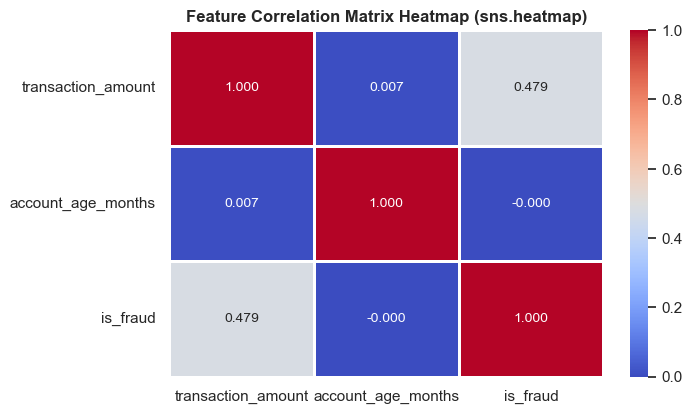

In [2]:
# 1. Calculate correlation table
corr = df[['transaction_amount', 'account_age_months', 'is_fraud']].corr()

# 2. Draw heatmap
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', cbar=True, linewidths=1, ax=ax)
ax.set_title('Feature Correlation Matrix Heatmap (sns.heatmap)', fontsize=12, fontweight='bold')

plt.show()

### 🔹 🔹 Hierarchical Clustermap: `sns.clustermap()`
Demonstrates how to use `🔹 Hierarchical Clustermap: `sns.clustermap()`` in Python. It provides a robust, standardized way to process, clean, and analyze datasets reliably and efficiently. **Tip:** `.apply()` runs a standard Python loop row-by-row. Whenever possible, use built-in vectorized operations (`df['a'] + df['b']`) which run up to 100x faster!.

**Syntax:** `# 1. Create a pivot table: average spend by Region and Card Type`


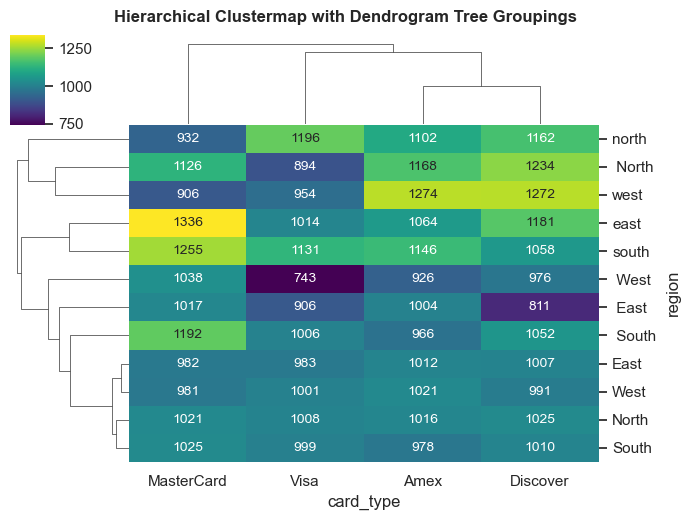

In [3]:
# 1. Create a pivot table: average spend by Region and Card Type
piv = df.pivot_table(index='region', columns='card_type', values='transaction_amount', aggfunc='mean')

# 2. Draw hierarchical cluster map
g = sns.clustermap(piv, cmap='viridis', annot=True, fmt='.0f', figsize=(7, 5))
g.fig.suptitle('Hierarchical Clustermap with Dendrogram Tree Groupings', y=1.03, fontsize=12, fontweight='bold')

plt.show()

### 🔹 🔹 Joint Plots: `sns.jointplot()`
Demonstrates how to use `🔹 Joint Plots: `sns.jointplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always check `df.shape` before and after merging to verify you didn't accidentally introduce Cartesian duplication or drop rows.

**Syntax:** `g = sns.jointplot(data=df.head(400), x='account_age_months', y='transaction_amount', kind='hex', color='darkblue', height=5.5)`


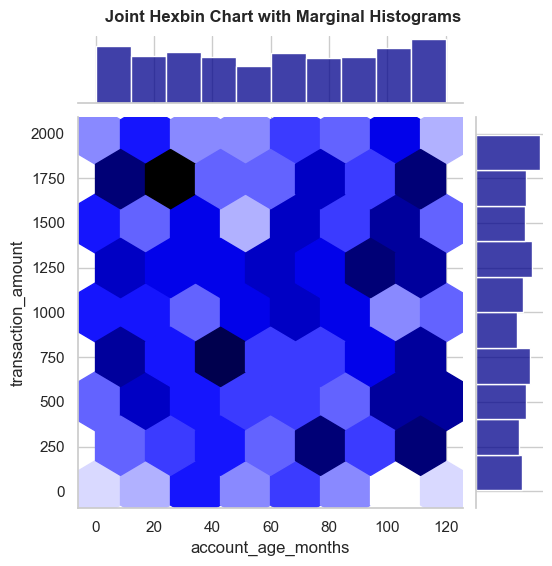

In [4]:
g = sns.jointplot(data=df.head(400), x='account_age_months', y='transaction_amount', kind='hex', color='darkblue', height=5.5)
g.fig.suptitle('Joint Hexbin Chart with Marginal Histograms', y=1.02, fontsize=12, fontweight='bold')

plt.show()

### 🔹 🔹 Pairwise Multi-Variable Grid: `sns.pairplot()`
Demonstrates how to use `🔹 Pairwise Multi-Variable Grid: `sns.pairplot()`` in Python. Visualizations turn complex numerical data into clear, intuitive graphics, helping you spot trends, patterns, and anomalies quickly. **Tip:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

**Syntax:** `g = sns.pairplot(df[['transaction_amount', 'account_age_months', 'is_fraud']].head(200), hue='is_fraud', palette='coolwarm', height=2.2)`


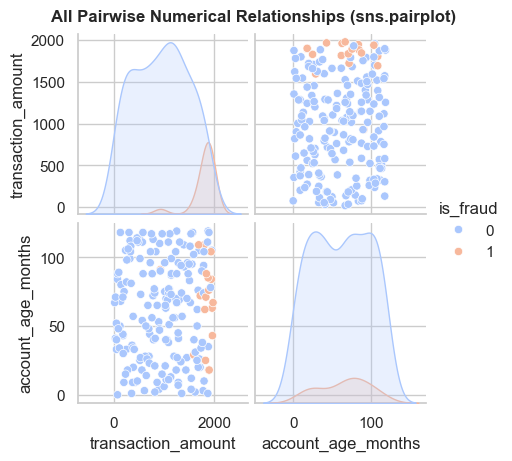

In [5]:
g = sns.pairplot(df[['transaction_amount', 'account_age_months', 'is_fraud']].head(200), hue='is_fraud', palette='coolwarm', height=2.2)
g.fig.suptitle('All Pairwise Numerical Relationships (sns.pairplot)', y=1.03, fontsize=12, fontweight='bold')

plt.show()